In [56]:
import numpy as np 
def calculate_bact_growth_exp(od, runtime_hours): 
    """ Calculate growth rate from OD measurements. 
    
    Note: this function assumes no dilutions.
    """

    log_od = np.log(od) 
    log_od_diff = log_od - log_od[0]
    growth_rate = log_od_diff / runtime_hours
    return growth_rate 

def calculate_bact_growth_steady(total_inc_dilution, run_time_hours, inc_vol): 
    """ Calculate growth rate from medium consumption.
    
    Note: this function assumes constant od. 
    """
    
    dil_per_hour = total_inc_dilution / run_time_hours
    gr_per_hour = dil_per_hour / inc_vol
    return gr_per_hour



In [21]:
import pandas as pd 
import seaborn as sns 

INC_VOL_ML = 30
TOTAL_VOL_ML = 300

state = pd.read_csv('../experiments/20240516_charlie_state.csv')
total_num_bursts = state['inc_dilution'].max()
state['inc_dilution_ml'] = state['inc_dilution'] * TOTAL_VOL_ML / total_num_bursts
state['runtime_h'] = (state['timestamp'] - state.loc[0, 'timestamp']) / 3600
state['growth_rate_steady'] = state.apply(lambda x: calculate_bact_growth_steady(x['inc_dilution_ml'], x['runtime_h'], INC_VOL_ML), axis=1)


/var/folders/5b/cl1vpvwx7z12hpb0ntpgryk40000gp/T/ipykernel_56583/2824222305.py:19: RuntimeWarning: invalid value encountered in scalar divide
  dil_per_hour = total_inc_dilution / run_time_hours


<Axes: xlabel='runtime_h', ylabel='inc_temp'>

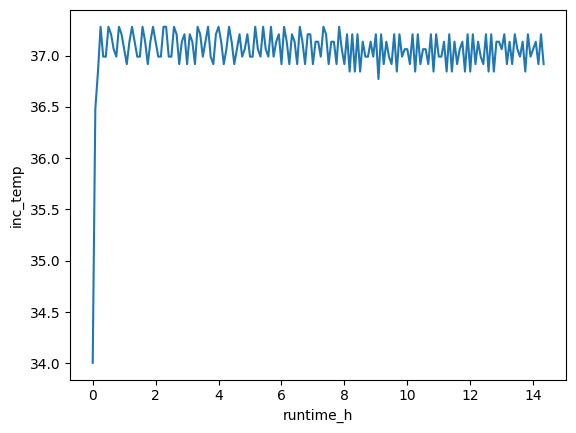

In [20]:
sns.lineplot(state, x='runtime_h', y='inc_temp')

<Axes: xlabel='runtime_h', ylabel='inc_od'>

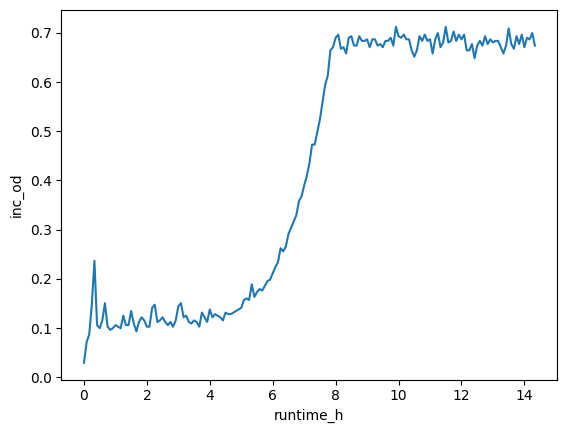

In [8]:
sns.lineplot(state, x='runtime_h', y='inc_od')

<Axes: xlabel='runtime_h', ylabel='inc_dilution_ml'>

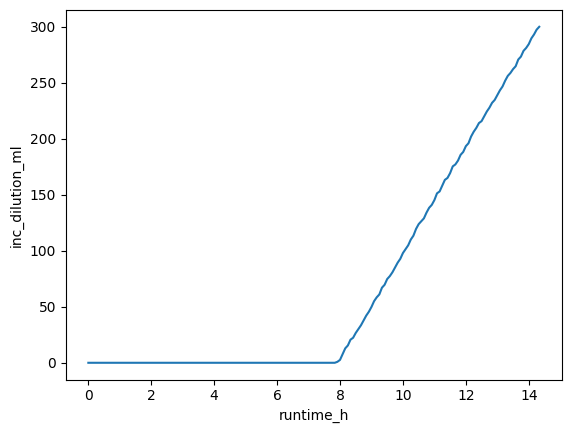

In [22]:
sns.lineplot(state, x='runtime_h', y='inc_dilution_ml')

volume per burst = 0.8595988538681948 ml = 0.028653295128939826 inc. volumes
100


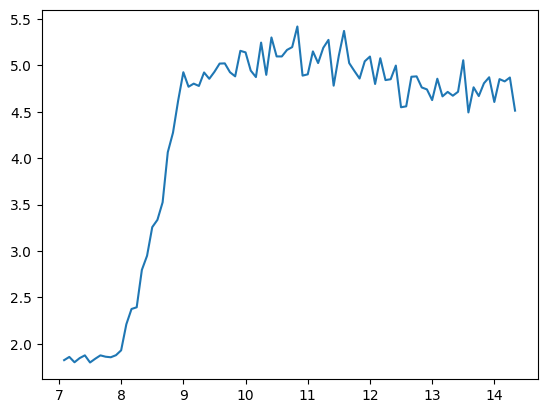

In [55]:
vol_per_burst_ml = TOTAL_VOL_ML / total_num_bursts
vol_per_burst_frac = vol_per_burst_ml / INC_VOL_ML
print(f'volume per burst = {vol_per_burst_ml} ml = {vol_per_burst_frac} inc. volumes')
#ts, gr = calculate_bact_growth2(state['inc_od'], state['inc_dilution'], vol_per_burst_frac, state['runtime_h'])
s = state[(state['runtime_h'] > 6) & (state['runtime_h'] < 15)]
print(len(s.index))
total_inc_bursts = s['inc_dilution'].values
od = s['inc_od'].values
burst_dilution = 1 - vol_per_burst_frac
runtime_hours = s['runtime_h'].values


# Calculate median for each window
window_size = 12
assert len(od) > window_size
num_bursts_per_interval = (total_inc_bursts[window_size:] - total_inc_bursts[:-window_size]) 
inc_dil_per_interval = num_bursts_per_interval * np.log(burst_dilution)
dt = runtime_hours[window_size:] - runtime_hours[:-window_size]
log_od = np.log(od)
log_od_diff = log_od[window_size:] - log_od[:-window_size]
growth_rate_log = (log_od_diff - inc_dil_per_interval) / dt
growth_rate = np.exp(growth_rate_log)
ts = runtime_hours[window_size:]
import matplotlib.pyplot as plt 
plt.plot(ts, growth_rate)

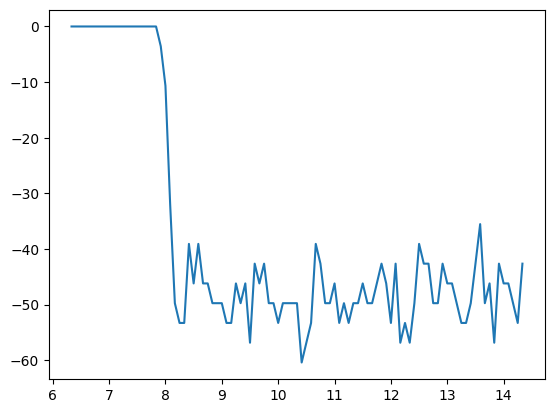

In [47]:
plt.plot(ts, inc_dil_per_interval)

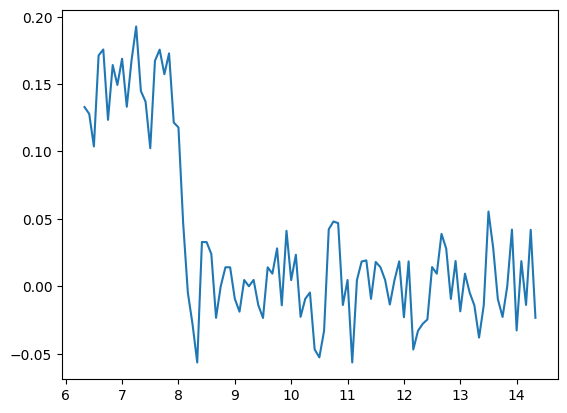

In [45]:
plt.plot(ts, log_od[window_size:] - log_od[:-window_size])

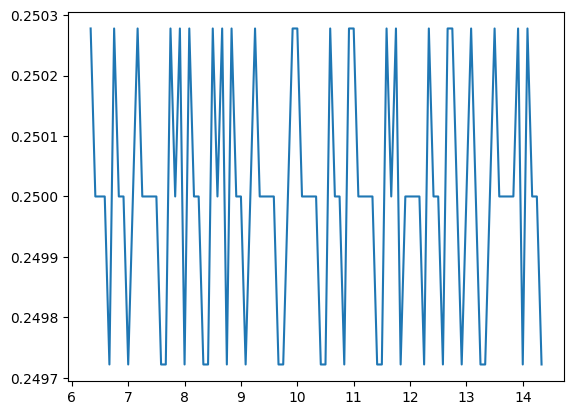

In [46]:
plt.plot(ts, dt)

<Axes: xlabel='t', ylabel='gr'>

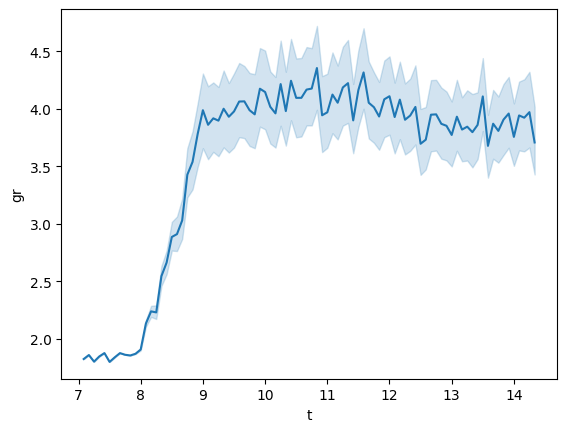

In [68]:
def calculate_bact_growth(od, total_inc_bursts, runtime_hours, inc_vol_ml, burst_size_ml, window_size=50): 
    # Calculate dilution per interval, measured in inc. volumes
    assert len(od) > window_size
    burst_dilution = 1 - burst_size_ml / inc_vol_ml
    num_bursts_per_interval = (total_inc_bursts[window_size:] - total_inc_bursts[:-window_size]) 
    inc_dil_per_interval = num_bursts_per_interval * np.log(burst_dilution)
    dt = runtime_hours[window_size:] - runtime_hours[:-window_size]
    log_od = np.log(od)
    log_od_diff = log_od[window_size:] - log_od[:-window_size]
    growth_rate_log = (log_od_diff - inc_dil_per_interval) / dt
    growth_rate = np.exp(growth_rate_log)
    ts = runtime_hours[window_size:]
    return ts, growth_rate

INC_VOL_ERR = 5
grs = pd.DataFrame({'t': [], 'gr': [], 'inc_vol': []})
x
for inc_vol in np.linspace(35-INC_VOL_ERR, 35+INC_VOL_ERR, num=10): 
    ts, gr = calculate_bact_growth(s['inc_od'].values, s['inc_dilution'].values, s['runtime_h'].values, inc_vol, vol_per_burst_ml, window_size=12)
    grs = pd.concat([grs, pd.DataFrame({'t': ts, 'gr': gr, 'inc_vol': inc_vol})])

sns.lineplot(grs, x='t', y='gr')

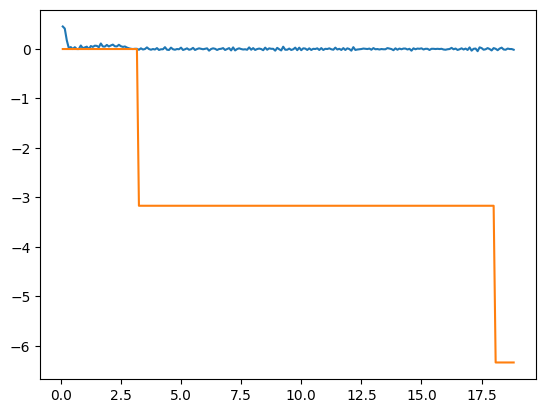

In [68]:
plt.plot(ts,log_od_diff)
plt.plot(ts,inc_dil_per_interval)

In [70]:
np.log(0.04205719778899303)

-3.168724735059427

<Axes: xlabel='runtime_h', ylabel='growth_rate'>

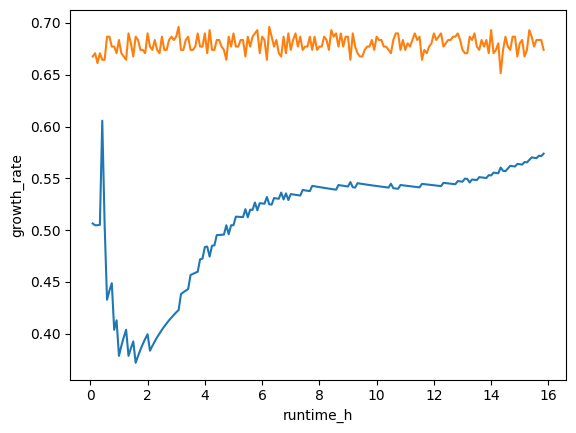

In [91]:
state_steady = state[state['runtime_h'] > 3].copy()
state_exp = state[state['runtime_h'] <= 3].copy()
state_steady['inc_dilution_ml2'] = state_steady['inc_dilution_ml2'] - state_exp['inc_dilution_ml2'].max()
state_steady['runtime_h'] = state_steady['runtime_h'] - state_exp['runtime_h'].max()
state_steady['growth_rate'] = state_steady.apply(lambda x: calculate_bact_growth_steady(x['inc_dilution_ml2'], x['runtime_h'], inc_vol=38), axis=1)
ax = sns.lineplot(state_steady, x='runtime_h', y='growth_rate')
sns.lineplot(state_steady, x='runtime_h', y='inc_od')


<Axes: xlabel='runtime_h', ylabel='growth_rate'>

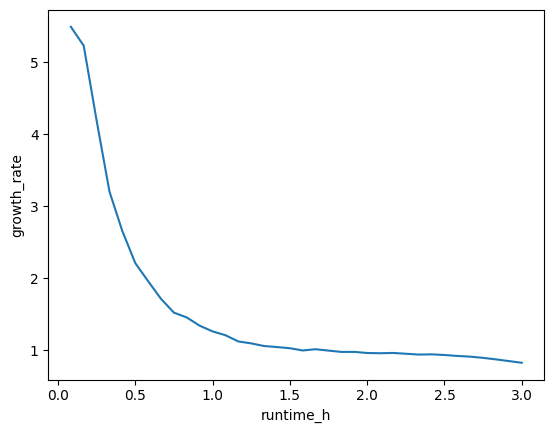

In [86]:
state_exp['growth_rate'] = calculate_bact_growth_exp(state_exp['inc_od'], state_exp['runtime_h'])
sns.lineplot(state_exp, x='runtime_h', y='growth_rate')